# Transitions Script! :D

In [23]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import matplotlib.gridspec as gridspec
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.dates as mdates
from pathlib import Path
#

In [24]:
file_list = [
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc',
    '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'
]

In [25]:
def get_cumulative_sediment_transitions(filenames, cumulative=False):
    if isinstance(filenames, str):
        filenames = [filenames]
        
    results = []
    depths_s2c, depths_c2m, depths_m2c = [], [], []
    
    # 1. Process each file and gather raw transition counts and depths
    for i, filename in enumerate(filenames):
        with xr.open_dataset(filename) as data:
            status = data.status.values
            status_now = status[:, :-1]
            status_next = status[:, 1:]
            
            # Extract depth at the 'status_now' time step
            z_now = data.z.values[:, :-1]
            
            # Transition Masks
            sediment_s_to_c = (status_now == 11) & (status_next == 12)
            sediment_c_to_m = (status_now == 12) & (status_next == 13)
            sediment_m_to_c = (status_now == 13) & (status_next == 12)
            
            # Store depths for median calculation
            depths_s2c.extend(z_now[sediment_s_to_c].tolist())
            depths_c2m.extend(z_now[sediment_c_to_m].tolist())
            depths_m2c.extend(z_now[sediment_m_to_c].tolist())
            
            # Count transitions
            c_s2c = np.count_nonzero(sediment_s_to_c)
            c_c2m = np.count_nonzero(sediment_c_to_m)
            c_m2c = np.count_nonzero(sediment_m_to_c)
            total = c_s2c + c_c2m + c_m2c
            
            results.append({
                'Year': i + 1,
                'count_s_to_c': c_s2c,
                'count_c_to_m': c_c2m,
                'count_m_to_c': c_m2c,
                'total_transitions': total
            })
            
    df = pd.DataFrame(results)
    
    # 2. Apply Cumulative Logic
    if cumulative and len(df) > 1:
        count_cols = ['count_s_to_c', 'count_c_to_m', 'count_m_to_c', 'total_transitions']
        baseline = df.loc[0, count_cols].copy()
        for i in range(1, len(df)):
            df.loc[i, count_cols] += baseline

    # 3. Calculate Percentages
    df['pct_s_to_c'] = np.where(df['total_transitions'] > 0, (df['count_s_to_c'] / df['total_transitions']) * 100, 0)
    df['pct_c_to_m'] = np.where(df['total_transitions'] > 0, (df['count_c_to_m'] / df['total_transitions']) * 100, 0)
    df['pct_m_to_c'] = np.where(df['total_transitions'] > 0, (df['count_m_to_c'] / df['total_transitions']) * 100, 0)

    # 4. Compute Mean and Standard Deviation
    pct_cols = ['pct_s_to_c', 'pct_c_to_m', 'pct_m_to_c']
    stats_df = df[pct_cols].agg(['mean', 'std']).T
    stats_df.index = ['S. S. to C. S.', 'S. C. to M. S.', 'M. S. to C. S.']
    
    # Calculate and append median depths
    med_s2c = np.nanmedian(depths_s2c) if depths_s2c else np.nan
    med_c2m = np.nanmedian(depths_c2m) if depths_c2m else np.nan
    med_m2c = np.nanmedian(depths_m2c) if depths_m2c else np.nan
    stats_df['median_depth'] = [med_s2c, med_c2m, med_m2c]
    
    return df, stats_df

In [26]:
def get_cumulative_resuspension_transitions(filenames, cumulative=False):
    if isinstance(filenames, str):
        filenames = [filenames]
        
    results = []
    d_ss2c, d_cs2c, d_ms2c, d_cs2m, d_ms2m = [], [], [], [], []
    
    for i, filename in enumerate(filenames):
        with xr.open_dataset(filename) as data:
            status = data.status.values
            status_now = status[:, :-1]
            status_next = status[:, 1:]
            z_now = data.z.values[:, :-1]
            
            all_ss_to_c = (status_now == 11) & (status_next == 2)
            all_cs_to_c = (status_now == 12) & (status_next == 2)
            all_ms_to_c = (status_now == 13) & (status_next == 2)
            all_cs_to_m = (status_now == 12) & (status_next == 3)
            all_ms_to_m = (status_now == 13) & (status_next == 3)
            
            d_ss2c.extend(z_now[all_ss_to_c].tolist())
            d_cs2c.extend(z_now[all_cs_to_c].tolist())
            d_ms2c.extend(z_now[all_ms_to_c].tolist())
            d_cs2m.extend(z_now[all_cs_to_m].tolist())
            d_ms2m.extend(z_now[all_ms_to_m].tolist())
            
            c_ss2c = np.count_nonzero(all_ss_to_c)
            c_cs2c = np.count_nonzero(all_cs_to_c)
            c_ms2c = np.count_nonzero(all_ms_to_c)
            c_cs2m = np.count_nonzero(all_cs_to_m)
            c_ms2m = np.count_nonzero(all_ms_to_m)
            
            total = c_ss2c + c_cs2c + c_ms2c + c_cs2m + c_ms2m
            results.append({'Year': i + 1, 'count_ss_to_c': c_ss2c, 'count_cs_to_c': c_cs2c, 'count_ms_to_c': c_ms2c, 'count_cs_to_m': c_cs2m, 'count_ms_to_m': c_ms2m, 'total_transitions': total})
            
    df = pd.DataFrame(results)
    
    if cumulative and len(df) > 1:
        count_cols = ['count_ss_to_c', 'count_cs_to_c', 'count_ms_to_c', 'count_cs_to_m', 'count_ms_to_m', 'total_transitions']
        baseline = df.loc[0, count_cols].copy()
        for i in range(1, len(df)):
            df.loc[i, count_cols] += baseline

    df['pct_ss_to_c'] = np.where(df['total_transitions'] > 0, (df['count_ss_to_c'] / df['total_transitions']) * 100, 0)
    df['pct_cs_to_c'] = np.where(df['total_transitions'] > 0, (df['count_cs_to_c'] / df['total_transitions']) * 100, 0)
    df['pct_ms_to_c'] = np.where(df['total_transitions'] > 0, (df['count_ms_to_c'] / df['total_transitions']) * 100, 0)
    df['pct_cs_to_m'] = np.where(df['total_transitions'] > 0, (df['count_cs_to_m'] / df['total_transitions']) * 100, 0)
    df['pct_ms_to_m'] = np.where(df['total_transitions'] > 0, (df['count_ms_to_m'] / df['total_transitions']) * 100, 0)

    pct_cols = ['pct_ss_to_c', 'pct_cs_to_c', 'pct_ms_to_c', 'pct_cs_to_m', 'pct_ms_to_m']
    stats_df = df[pct_cols].agg(['mean', 'std']).T
    stats_df.index = ['S. S. - C. W. C.', 'C. S. - C. W. C.', 'M. S. - C. W. C.', 'C. S. - M. W. C.', 'M. S - M. W. C.']
    
    stats_df['median_depth'] = [
        np.nanmedian(d_ss2c) if d_ss2c else np.nan,
        np.nanmedian(d_cs2c) if d_cs2c else np.nan,
        np.nanmedian(d_ms2c) if d_ms2c else np.nan,
        np.nanmedian(d_cs2m) if d_cs2m else np.nan,
        np.nanmedian(d_ms2m) if d_ms2m else np.nan
    ]
    
    return df, stats_df

In [27]:
def get_cumulative_water_transitions(filenames, cumulative=False):
    if isinstance(filenames, str):
        filenames = [filenames]
        
    results = []
    d_s2c, d_c2m, d_m2c = [], [], []
    
    for i, filename in enumerate(filenames):
        with xr.open_dataset(filename) as data:
            status = data.status.values
            status_now = status[:, :-1]
            status_next = status[:, 1:]
            z_now = data.z.values[:, :-1]
            
            water_s_to_c = (status_now == 1) & (status_next == 2)
            water_c_to_m = (status_now == 2) & (status_next == 3)
            water_m_to_c = (status_now == 3) & (status_next == 2)
            
            d_s2c.extend(z_now[water_s_to_c].tolist())
            d_c2m.extend(z_now[water_c_to_m].tolist())
            d_m2c.extend(z_now[water_m_to_c].tolist())
            
            c_s2c = np.count_nonzero(water_s_to_c)
            c_c2m = np.count_nonzero(water_c_to_m)
            c_m2c = np.count_nonzero(water_m_to_c)
            total = c_s2c + c_c2m + c_m2c
            
            results.append({'Year': i + 1, 'count_s_to_c': c_s2c, 'count_c_to_m': c_c2m, 'count_m_to_c': c_m2c, 'total_transitions': total})
            
    df = pd.DataFrame(results)
    
    if cumulative and len(df) > 1:
        count_cols = ['count_s_to_c', 'count_c_to_m', 'count_m_to_c', 'total_transitions']
        baseline = df.loc[0, count_cols].copy()
        for i in range(1, len(df)):
            df.loc[i, count_cols] += baseline

    df['pct_s_to_c'] = np.where(df['total_transitions'] > 0, (df['count_s_to_c'] / df['total_transitions']) * 100, 0)
    df['pct_c_to_m'] = np.where(df['total_transitions'] > 0, (df['count_c_to_m'] / df['total_transitions']) * 100, 0)
    df['pct_m_to_c'] = np.where(df['total_transitions'] > 0, (df['count_m_to_c'] / df['total_transitions']) * 100, 0)

    pct_cols = ['pct_s_to_c', 'pct_c_to_m', 'pct_m_to_c']
    stats_df = df[pct_cols].agg(['mean', 'std']).T
    stats_df.index = ['S. W.C. - C. W. C.', 'C. W.C. - M. W. C.', 'M. W.C. - C. W. C.']
    
    stats_df['median_depth'] = [
        np.nanmedian(d_s2c) if d_s2c else np.nan,
        np.nanmedian(d_c2m) if d_c2m else np.nan,
        np.nanmedian(d_m2c) if d_m2c else np.nan
    ]
    
    return df, stats_df

In [28]:
def get_cumulative_sedimentation_transitions(filenames, cumulative=False):
    if isinstance(filenames, str):
        filenames = [filenames]
        
    results = []
    d_s2ss, d_c2cs, d_m2ms = [], [], []
    
    for i, filename in enumerate(filenames):
        with xr.open_dataset(filename) as data:
            status = data.status.values
            status_now = status[:, :-1]
            status_next = status[:, 1:]
            z_now = data.z.values[:, :-1]
            
            water_s_to_ss = (status_now == 1) & (status_next == 11)
            water_c_to_cs = (status_now == 2) & (status_next == 12)
            water_m_to_ms = (status_now == 3) & (status_next == 13)
            
            d_s2ss.extend(z_now[water_s_to_ss].tolist())
            d_c2cs.extend(z_now[water_c_to_cs].tolist())
            d_m2ms.extend(z_now[water_m_to_ms].tolist())
            
            c_s2ss = np.count_nonzero(water_s_to_ss)
            c_c2cs = np.count_nonzero(water_c_to_cs)
            c_m2ms = np.count_nonzero(water_m_to_ms)
            total = c_s2ss + c_c2cs + c_m2ms
            
            results.append({'Year': i + 1, 'count_s_to_ss': c_s2ss, 'count_c_to_cs': c_c2cs, 'count_m_to_ms': c_m2ms, 'total_transitions': total})
            
    df = pd.DataFrame(results)
    
    if cumulative and len(df) > 1:
        count_cols = ['count_s_to_ss', 'count_c_to_cs', 'count_m_to_ms', 'total_transitions']
        baseline = df.loc[0, count_cols].copy()
        for i in range(1, len(df)):
            df.loc[i, count_cols] += baseline

    df['pct_s_to_ss'] = np.where(df['total_transitions'] > 0, (df['count_s_to_ss'] / df['total_transitions']) * 100, 0)
    df['pct_c_to_cs'] = np.where(df['total_transitions'] > 0, (df['count_c_to_cs'] / df['total_transitions']) * 100, 0)
    df['pct_m_to_ms'] = np.where(df['total_transitions'] > 0, (df['count_m_to_ms'] / df['total_transitions']) * 100, 0)

    pct_cols = ['pct_s_to_ss', 'pct_c_to_cs', 'pct_m_to_ms']
    stats_df = df[pct_cols].agg(['mean', 'std']).T
    stats_df.index = ['S. W.C. - S. S.', 'C. W.C. - C. S.', 'M. W.C. - M. S.']
    
    stats_df['median_depth'] = [
        np.nanmedian(d_s2ss) if d_s2ss else np.nan,
        np.nanmedian(d_c2cs) if d_c2cs else np.nan,
        np.nanmedian(d_m2ms) if d_m2ms else np.nan
    ]
    
    return df, stats_df

In [29]:
yearly_data_sediment, summary_stats_sediment = get_cumulative_sediment_transitions(file_list, cumulative=True)

In [30]:
yearly_data_resuspension, summary_stats_resuspension = get_cumulative_resuspension_transitions(file_list, cumulative=True)

In [31]:
yearly_data_water, summary_stats_water = get_cumulative_water_transitions(file_list, cumulative=True)

In [32]:
yearly_data_sedimentation, summary_stats_sedimentation = get_cumulative_sedimentation_transitions(file_list, cumulative=True)

# Plot

In [38]:
summary_stats_water

,mean,std,median_depth
S. W.C. - C. W. C.,0.000049,0.000012,73.268960
C. W.C. - M. W. C.,50.010766,0.002828,294.790128
M. W.C. - C. W. C.,49.989185,0.002834,294.903535


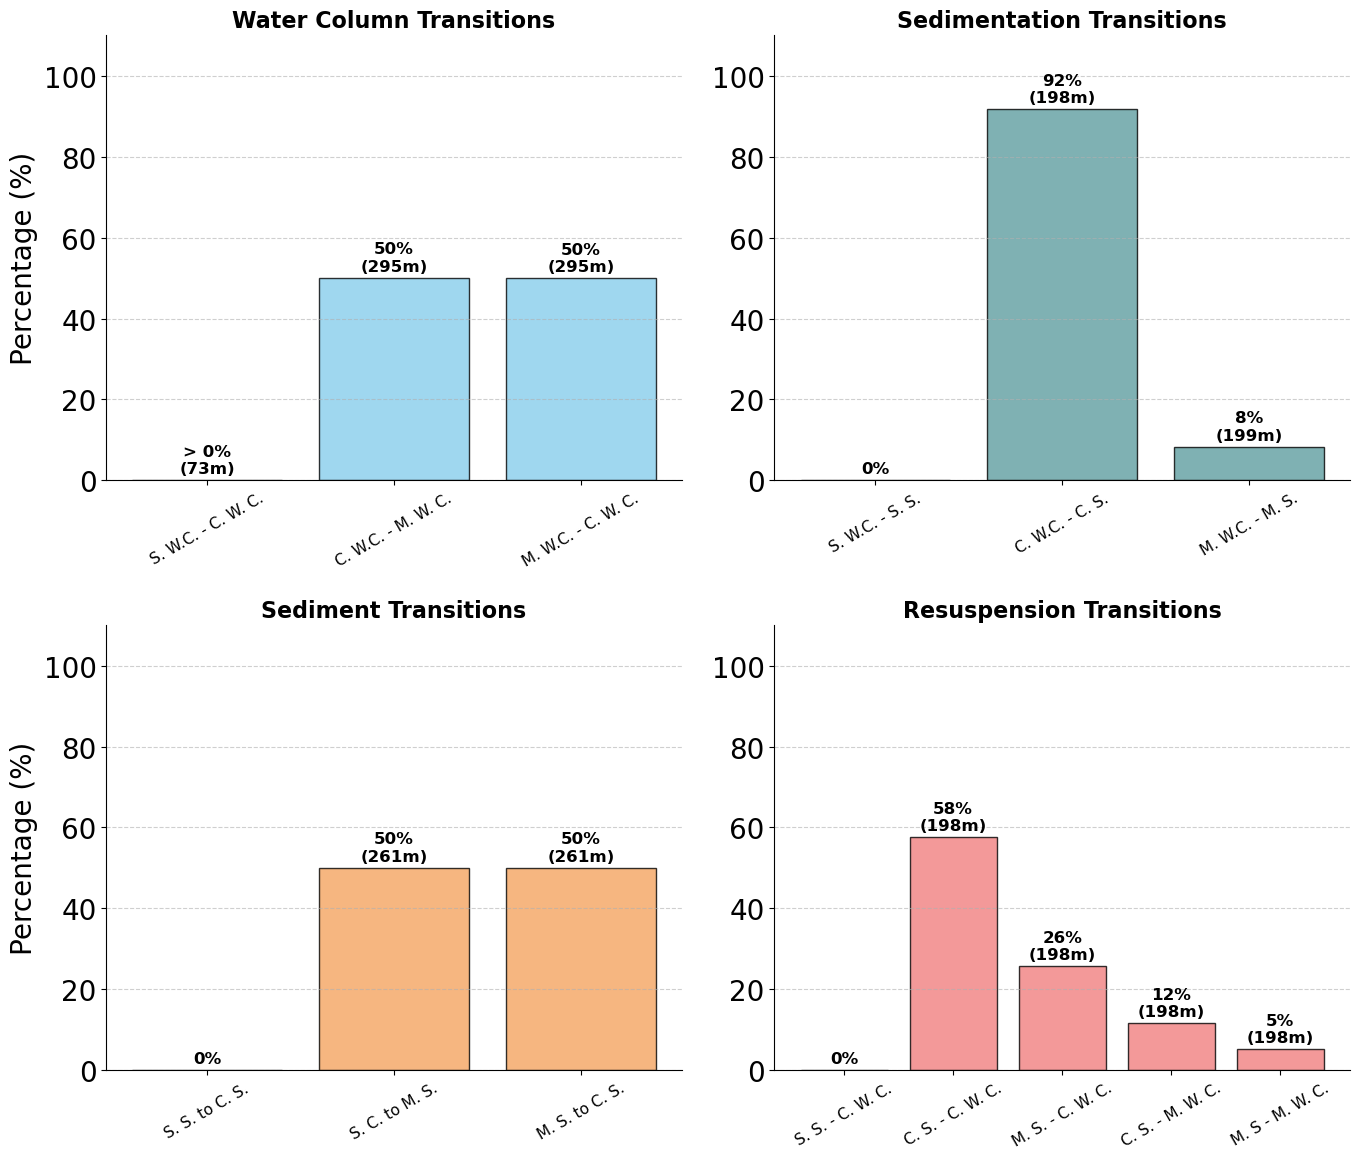

In [37]:
plt.rcParams.update({'font.size': 20})

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

# --- Helper function for labels ---
def get_custom_labels(stats_df):
    labels = []
    for pct, depth in zip(stats_df['mean'], stats_df['median_depth']):
        
        # 1. Format the percentage text to catch tiny, non-zero values
        if 0 < pct < 1:
            pct_text = "> 0%"
        else:
            pct_text = f"{pct:.0f}%"
            
        # 2. Combine with depth data if applicable
        if pct == 0 or np.isnan(depth):
            labels.append(pct_text)
        else:
            labels.append(f"{pct_text}\n({depth:.0f}m)")
            
    return labels

# --- Plot Water Column Transitions ---
bars_water = axs[0, 0].bar(summary_stats_water.index, 
                           summary_stats_water['mean'], 
                           color='skyblue', edgecolor='black', alpha=0.8)
axs[0, 0].bar_label(bars_water, labels=get_custom_labels(summary_stats_water), 
                    padding=3, fontsize=12, fontweight='bold', linespacing=1.2)
axs[0, 0].set_title('Water Column Transitions', fontsize=16, fontweight='bold')
axs[0, 0].set_ylabel('Percentage (%)')

# --- Plot Sediment Transitions ---
bars_sediment = axs[1, 0].bar(summary_stats_sediment.index, 
                              summary_stats_sediment['mean'], 
                              color='sandybrown', edgecolor='black', alpha=0.8)
axs[1, 0].bar_label(bars_sediment, labels=get_custom_labels(summary_stats_sediment), 
                    padding=3, fontsize=12, fontweight='bold', linespacing=1.2)
axs[1, 0].set_title('Sediment Transitions', fontsize=16, fontweight='bold')
axs[1, 0].set_ylabel('Percentage (%)')


# --- Plot Sedimentation Transitions ---
bars_sedimentation = axs[0, 1].bar(summary_stats_sedimentation.index, 
                                   summary_stats_sedimentation['mean'], 
                                   color='cadetblue', edgecolor='black', alpha=0.8)
axs[0, 1].bar_label(bars_sedimentation, labels=get_custom_labels(summary_stats_sedimentation), 
                    padding=3, fontsize=12, fontweight='bold', linespacing=1.2)
axs[0, 1].set_title('Sedimentation Transitions', fontsize=16, fontweight='bold')

# --- Plot Resuspension Transitions ---
bars_resuspension = axs[1, 1].bar(summary_stats_resuspension.index, 
                                  summary_stats_resuspension['mean'], 
                                  color='lightcoral', edgecolor='black', alpha=0.8)
axs[1, 1].bar_label(bars_resuspension, labels=get_custom_labels(summary_stats_resuspension), 
                    padding=3, fontsize=12, fontweight='bold', linespacing=1.2)
axs[1, 1].set_title('Resuspension Transitions', fontsize=16, fontweight='bold')


# --- Formatting ---
for ax in axs.flat:
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    
    # Scale Y limit to make room for the taller double-line text labels
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, 110)
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

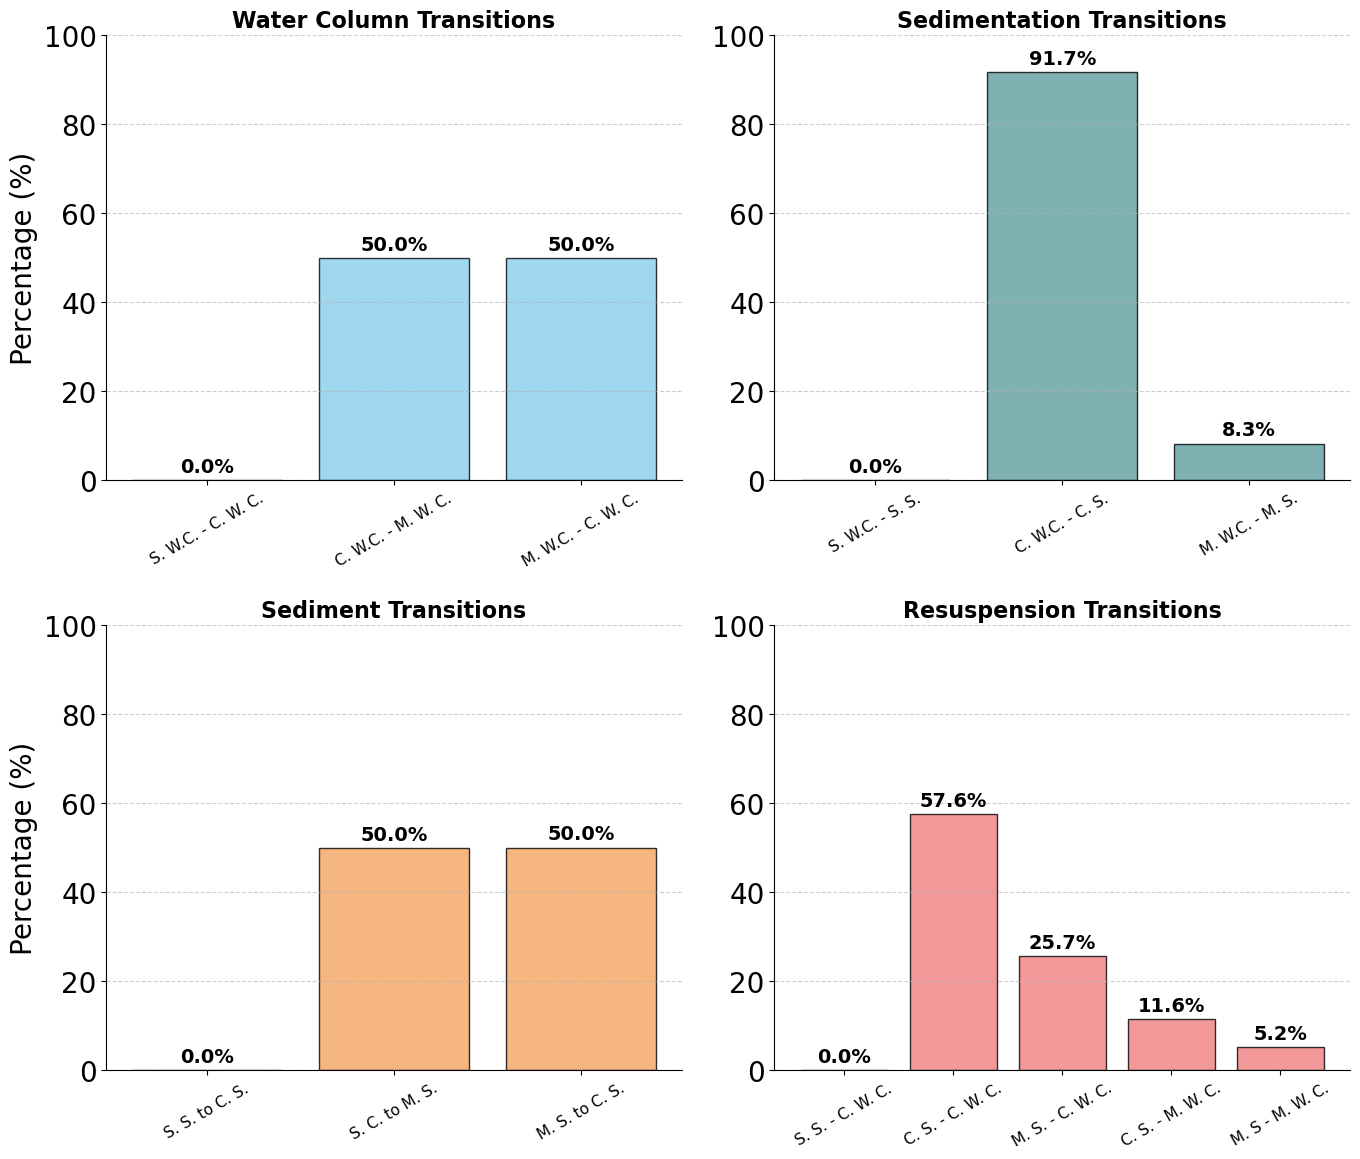

In [19]:
plt.rcParams.update({'font.size': 20})

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

# 
bars_water = axs[0, 0].bar(summary_stats_water.index, 
                           summary_stats_water['mean'], 
                           color='skyblue', edgecolor='black', alpha=0.8)
#
axs[0, 0].bar_label(bars_water, fmt='%.1f%%', padding=3, fontsize=14, fontweight='bold')
axs[0, 0].set_title('Water Column Transitions', fontsize=16, fontweight='bold')
axs[0, 0].set_ylabel('Percentage (%)')
#
bars_sediment = axs[1, 0].bar(summary_stats_sediment.index, 
                              summary_stats_sediment['mean'], 
                              color='sandybrown', edgecolor='black', alpha=0.8)
axs[1, 0].bar_label(bars_sediment, fmt='%.1f%%', padding=3, fontsize=14, fontweight='bold')
axs[1, 0].set_title('Sediment Transitions', fontsize=16, fontweight='bold')
axs[1, 0].set_ylabel('Percentage (%)')


# 
bars_sedimentation = axs[0, 1].bar(summary_stats_sedimentation.index, 
                                   summary_stats_sedimentation['mean'], 
                                   color='cadetblue', edgecolor='black', alpha=0.8)
axs[0, 1].bar_label(bars_sedimentation, fmt='%.1f%%', padding=3, fontsize=14, fontweight='bold')
axs[0, 1].set_title('Sedimentation Transitions', fontsize=16, fontweight='bold')

#
bars_resuspension = axs[1, 1].bar(summary_stats_resuspension.index, 
                                  summary_stats_resuspension['mean'], 
                                  color='lightcoral', edgecolor='black', alpha=0.8)
axs[1, 1].bar_label(bars_resuspension, fmt='%.1f%%', padding=3, fontsize=14, fontweight='bold')
axs[1, 1].set_title('Resuspension Transitions', fontsize=16, fontweight='bold')


for ax in axs.flat:
    #
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, 100)# * 1.15)
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()